In [ ]:
#installing Required libraries
%mamba install pandas
%mamba install numpy
%mamba install matplotlib
%mamba install seaborn

In [7]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#set plot style
plt.style.use("ggplot")

In [8]:
df=pd.read_csv("online_retail.csv",encoding="unicode_escape")

In [9]:
#Understanding the data
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [10]:
df.shape

(541910, 8)

In [11]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 22.7 MB


In [13]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [14]:
#Checking missing values
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [15]:
#Checking duplicare records
df.duplicated().sum()

np.int64(5268)

In [16]:
#Removing duplicates from
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [17]:
#drop null values
df.dropna(inplace=True)
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [30]:
df.dropna(subset=['InvoiceDate'],inplace=True)

In [31]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales,year,month,day,weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010.0,1.0,12.0,Tuesday
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,12.0,Tuesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010.0,1.0,12.0,Tuesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,12.0,Tuesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,12.0,Tuesday


In [20]:
#Removing invalid data
df=df[df['Quantity'] > 0]

In [21]:
df=df[df['Price'] > 0]

In [22]:
#Creating sales column
df['sales']=df['Quantity']*df['Price']

In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [32]:
#cover invoice date from str to date
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'],errors='coerce')

In [33]:
df['year']=df['InvoiceDate'].dt.year

In [34]:
df['month']=df['InvoiceDate'].dt.month

In [35]:
df['day']=df['InvoiceDate'].dt.day

In [36]:
df['weekday']=df['InvoiceDate'].dt.day_name()

In [37]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales,year,month,day,weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,1,12,Tuesday
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,1,12,Tuesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday


In [38]:
df.shape


(166364, 13)

In [39]:
#Total Revenue
df['sales'].sum()

np.float64(3865481.08)

In [40]:
#Avg order vale
df['sales'].mean()

np.float64(23.235081387800246)

In [ ]:
#Top 10 products

In [41]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales,year,month,day,weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,1,12,Tuesday
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,1,12,Tuesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,1,12,Tuesday


In [42]:
top_products=df.groupby('Description')['sales'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER               62383.41
WHITE HANGING HEART T-LIGHT HOLDER     47903.18
PICNIC BASKET WICKER 60 PIECES         39619.50
JUMBO BAG RED RETROSPOT                37977.38
POSTAGE                                35265.15
ASSORTED COLOUR BIRD ORNAMENT          28457.85
PARTY BUNTING                          28236.87
Manual                                 26016.79
BLACK RECORD COVER FRAME               22443.26
Name: sales, dtype: float64

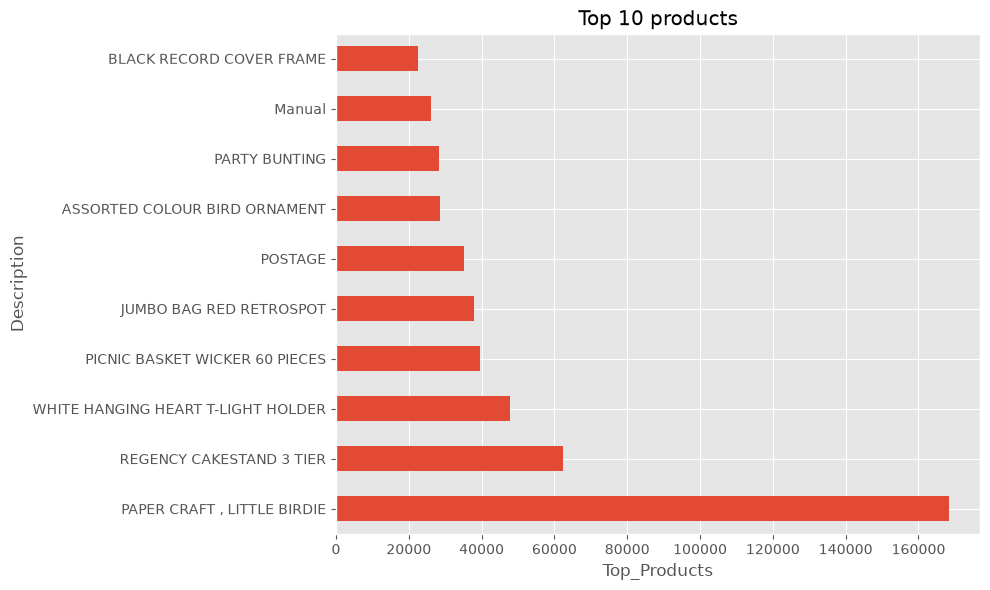

In [56]:
plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.xlabel("Top_Products")
plt.title("Top 10 products")
plt.tight_layout()
plt.savefig("Top_10_products.png",dpi=300)
plt.show()

In [45]:
#Monthly sales
monthly_sales=df.groupby("month")['sales'].sum()
monthly_sales

month
1     285757.29
2     256052.15
3     284865.29
4     328429.99
5     352632.71
6     335653.11
7     376040.25
8     295838.50
9     459324.14
10    324485.24
11    344620.67
12    221781.74
Name: sales, dtype: float64

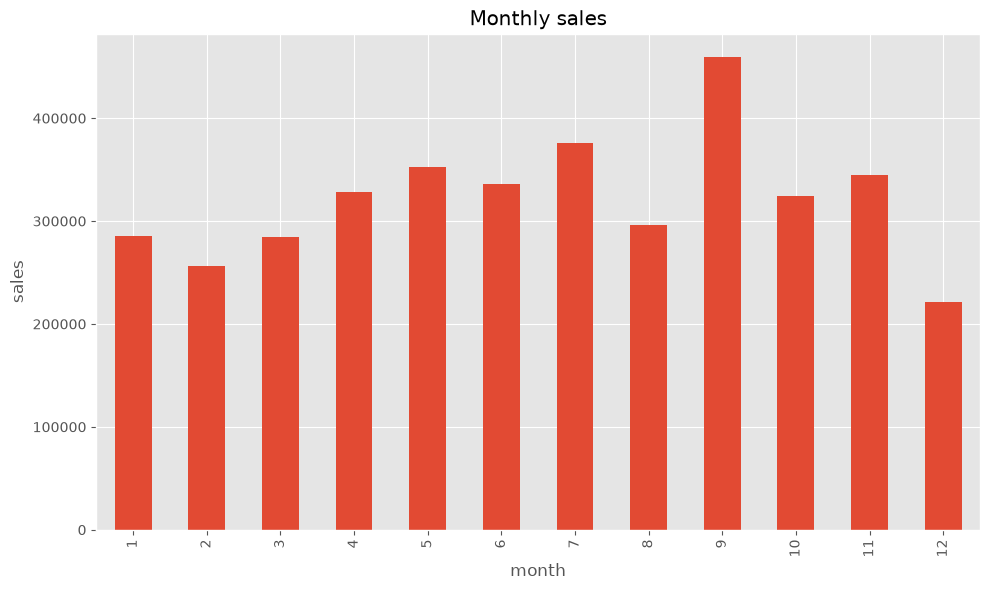

In [57]:
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='bar')
plt.ylabel("sales")
plt.title("Monthly sales")
plt.tight_layout()
plt.savefig("Monthly_sales",dpi=300)
plt.show()

In [47]:
#Country_wise_sales
country_sales=df.groupby('Country')['sales'].sum().sort_values(ascending=False).head(10)

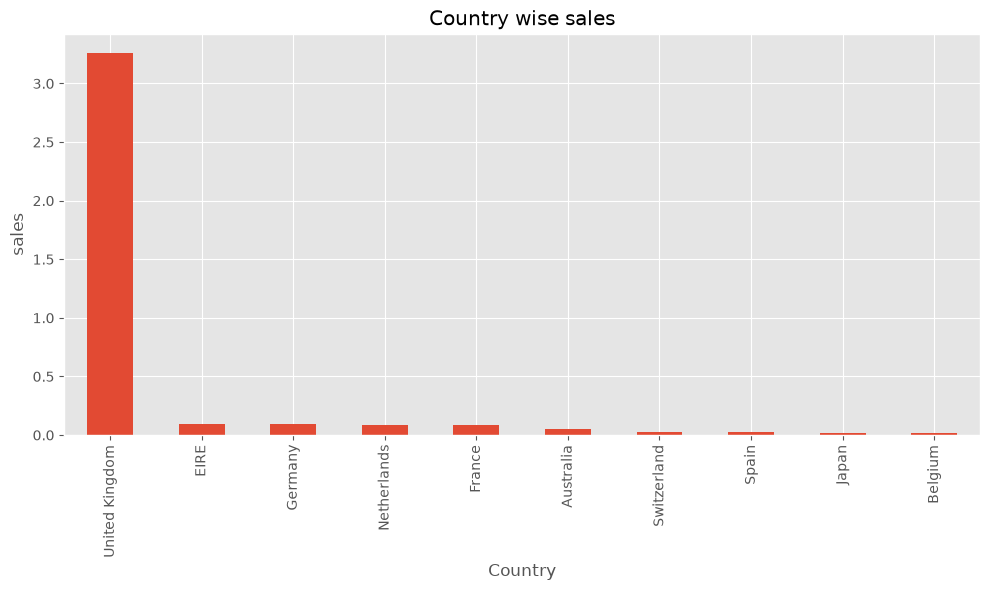

In [50]:
plt.figure(figsize=(10,6))
(country_sales/1e6).plot(kind='bar')
plt.ylabel("sales")
plt.title("Country wise sales")
plt.tight_layout()
plt.savefig("Country_wise_sales",dpi=300)
plt.show()

In [54]:
#Top customers
top_customers=df.groupby('Customer ID')['sales'].sum().sort_values(ascending=False).head(10)

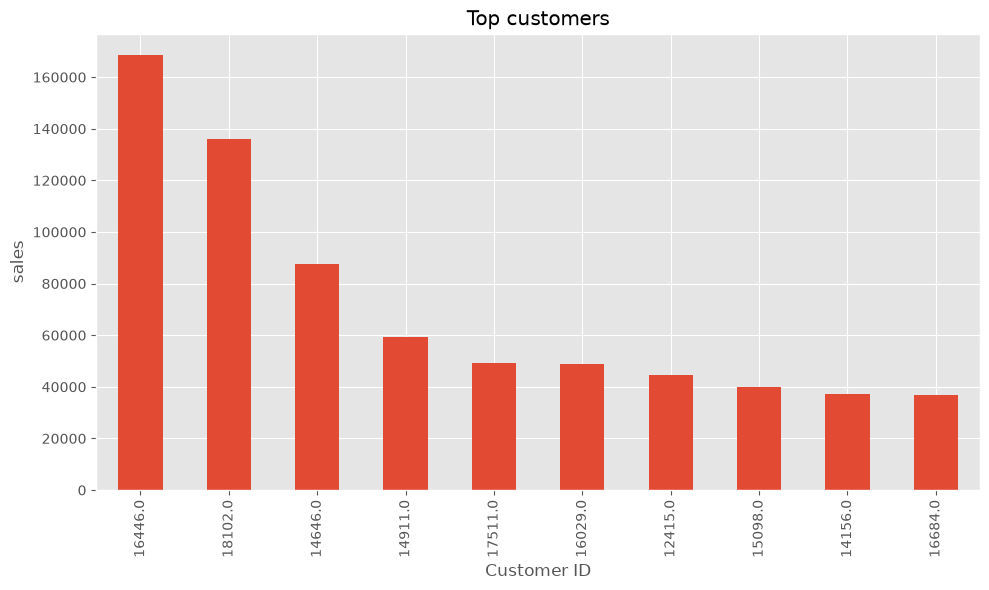

In [55]:
plt.figure(figsize=(10,6))
top_customers.plot(kind='bar')
plt.ylabel("sales")
plt.title("Top customers")
plt.tight_layout()
plt.savefig("Top_customers",dpi=300)
plt.show()

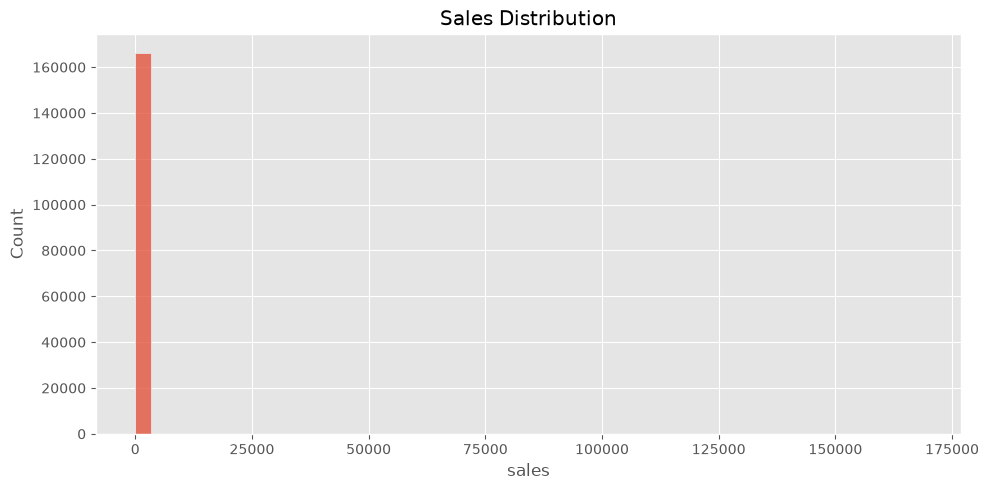

In [60]:
#sales distributtion
plt.figure(figsize=(10,5))
sns.histplot(df['sales'],bins=50)
plt.title("Sales Distribution")
plt.tight_layout()
plt.savefig("Sales_Distribution",dpi=300)
plt.show()

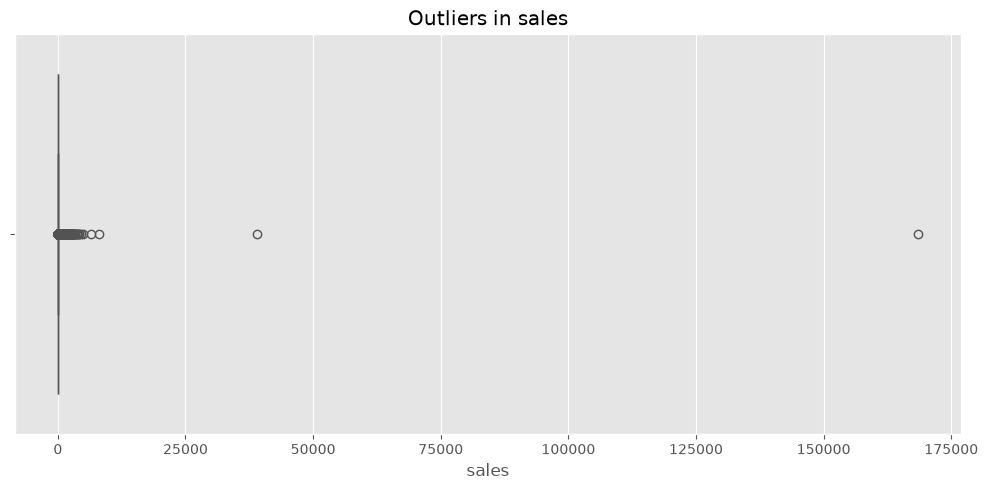

In [61]:
#outliers in sales
plt.figure(figsize=(10,5))
sns.boxplot(x=df['sales'])
plt.title("Outliers in sales")
plt.tight_layout()
plt.savefig("Outliers_in_sales",dpi=300)
plt.show()

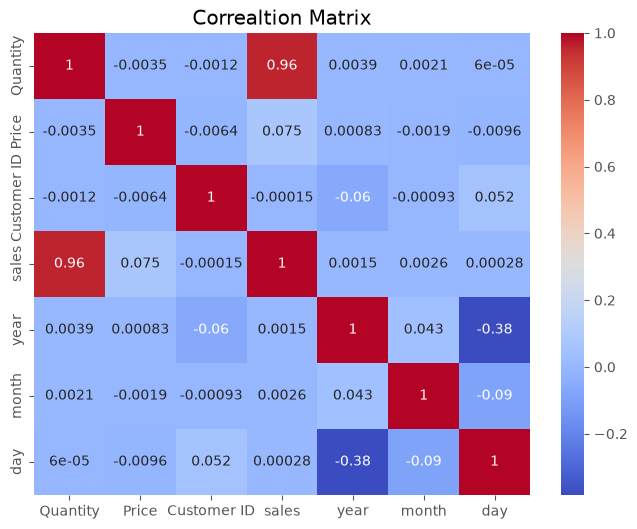

In [68]:
#Correlation heat map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correaltion Matrix")
plt.savefig("Correaltion_Matrix",dpi=300)
plt.show()
          

In [65]:
#Orders by weekday
weekday_orders=df["weekday"].value_counts()
weekday_orders

weekday
Friday       28294
Tuesday      27501
Thursday     25498
Sunday       24034
Saturday     22737
Monday       20887
Wednesday    17413
Name: count, dtype: int64

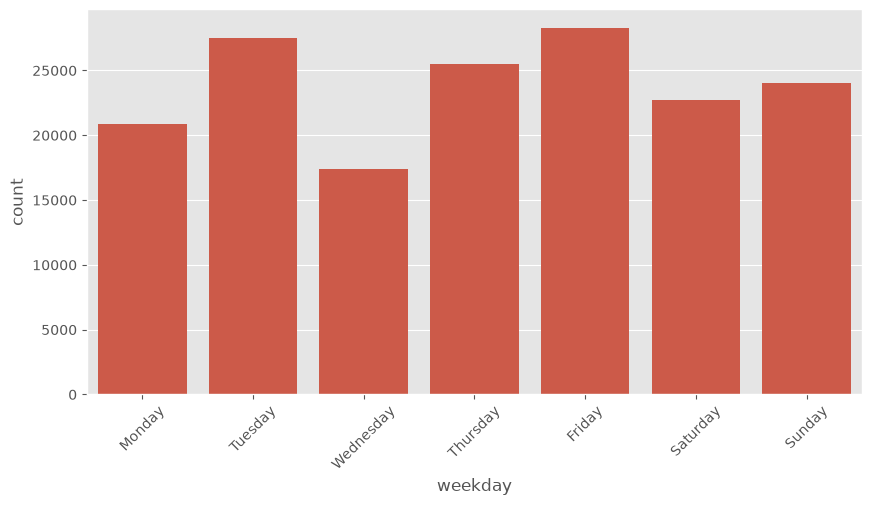

In [67]:
plt.figure(figsize=(10,5))
sns.countplot(x="weekday",
              data=df,
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
             )
plt.xticks(rotation=45)
plt.show()

In [71]:
np.median(df['sales'])

np.float64(11.9)

In [70]:
np.std(df["sales"])

np.float64(430.6773180839802)